In [1]:
import matplotlib.pyplot as plt
import arviz as az
import jax

jax.config.update("jax_enable_x64", True)

from lqg.io import load_tracking_data

data, blob_widths = load_tracking_data(data_path="../data/")
data.shape

(6, 20, 1068, 2)

In [16]:
from jax import random
import jax.numpy as jnp

from lqg.infer.mle import max_likelihood, Box, LogBox
from lqg.tracking import BoundedActor

# some parameters we set to  fixed values, while the rest are estimated from the data
fixed_params = {
    "dt": 1 / 60.0,
}


# We can define constraints for the optimization. 
# Here, we assume that the parameters are positive and within a reasonable range. 
# The Box and LogBox classes define the lower and upper bounds for each parameter.
# For the LogBox, the optimization will be performed in log-space, which is useful for parameters that can vary over several orders of magnitude.
params_constraints = {
    "action_cost": LogBox(low=1e-7, high=1e-2),
    "sigma_target": Box(0.01, 100.0),
    "action_variability": Box(low=0.01, high=2.0),
    "sigma_cursor": Box(low=0.01, high=100.0),
}

key = random.PRNGKey(0)
estimated_params = []
x_sim = []
for x in data:
    
    params = max_likelihood(
        key=random.PRNGKey(7),
        x=x, # observed data
        constraints=params_constraints, # constraints for the optimization
        model=BoundedActor, # model class to use for model fitting
        max_steps=1000, # maximum number of optimization steps
        num_restarts=20, # number of random restarts for optimization
        **fixed_params # fixed parameters to pass to the model class (these will not be estimated)
    )

    key, subkey = random.split(key)
    # simulate the model with the estimated parameters to see how well it fits the data
    x_sim.append(BoundedActor(**params, **fixed_params).simulate(subkey, n=20))
    estimated_params.append(params)

# just aggregate the esimated parameters into a single dict of arrays for plotting
estimated_params = {k: jnp.array([p[k] for p in estimated_params]) for k in estimated_params[0]}

x_sim = jnp.stack(x_sim, axis=0)

Text(0, 0.5, 'Estimated perceptual uncertainty')

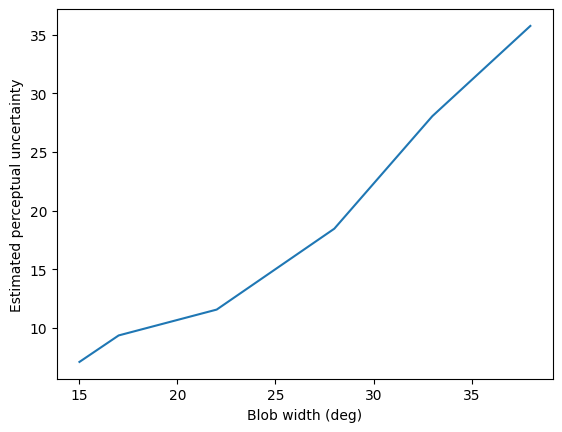

In [17]:
plt.plot(blob_widths, estimated_params["sigma_target"])
plt.xlabel("Blob width (deg)")
plt.ylabel("Estimated perceptual uncertainty")

(-10.0, 60.0)

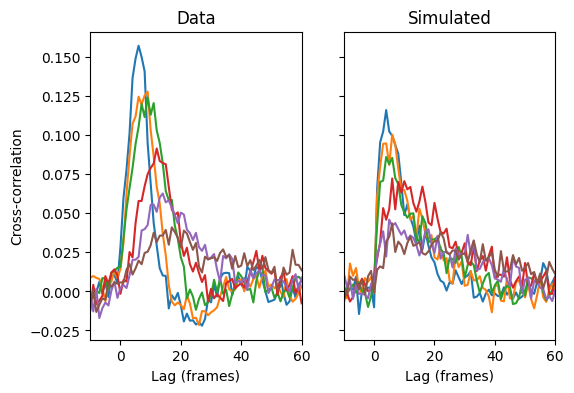

In [18]:
from lqg import xcorr

vels = jnp.diff(data, axis=-2)
vels_sim = jnp.diff(x_sim, axis=-2)

lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=60)
lags, correls_sim = xcorr(vels_sim[..., 1], vels_sim[..., 0], maxlags=60)


f, ax = plt.subplots(1, 2, figsize=(6, 4), sharey=True, sharex=True)
ax[0].plot(lags, correls.mean(axis=1).T, label="data")
ax[1].plot(lags, correls_sim.mean(axis=1).T, label="simulated")
ax[0].set_title("Data")
ax[1].set_title("Simulated")
ax[0].set_xlabel("Lag (frames)")
ax[1].set_xlabel("Lag (frames)")
ax[0].set_ylabel("Cross-correlation")
ax[0].set_xlim(-10, 60)